<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# Time Series Analysis
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>


### Programmes

* Data Science Accelerator: Time Series Analysis and forecasting



### Learning Objectives
* Describe a time series as a composition between trends, seasonality and residuals
* Describe the core terminology of time series analysis esp., lag, stationarity, additive, multiplicative, ...
* Perform autocorrelation analysis
* Build and train a time series model
* Compare and contrast various approaches to time series analysis



## Content

### Overview

Diagnostics for time series forecasting
- Stationarity
- Challenge: Check for stationarity by eyeballing the time series graph
- ADF Test    
- Differencing
- Challenge: Re-run ACF and ADF test, is our differenced time series stationary?
- Challenge: Apply seasonal differencing with .diff(m) to reduce seasonality

Approaches to time series forecasting
- What approaches to Time Series forecasting are there?
- How do you evaluate a Time Series model?
- How do you build a Time Series model in python?
- Modelling with AutoARIMA
- Challenge: Report key parameters of a time series model and intepret them
- Challenge: Train and evaluate an SES model and compare the performance
- Challenge: Real-World Time Series Analysis

Machine learning in time series forecasting and evaluation methods
- What machine learning approaches to Time Series forecasting are there?
- How do you evaluate a Time Series model?
- How do you build a Time Series model in python?
- Modeling using tree methods
- Challenge: Report key parameters of a time series model and intepret them
- Challenge: Train and evaluate a random forest model and compare the performance
- Challenge: Train and evaluate a SARIMAX and compare the performance
- Challenge: Evaluation on time series machine learning algorithms

### Introductions

#### Purpose: What is the aim of the content?

This workshop continues building on valuable skills for working with time-dependent data. You will get familiar with the core terminology, methods used and the components of a time series. You will also be introduced to how to build and train a time series forecasting model.

#### Objectives: What will I learn?

* Describe a time series as a composition between trends, seasonality and residuals
* Describe the core terminology of time series analysis e.g. lags, stationarity, decomposition etc.
* Perform autocorrelation analysis
* Build and train a time series model
* Compare and contrast various approaches to time series analysis

#### Process: How will I learn this content?

##### Outline

- Menti quiz
- Group discussions
- Coding demos
- Coding challenges

#### Menti

[www.menti.com](www.menti.com)

#### Applications: Why study time series analysis?

Analyzing historical data and identifying patterns and trends in time-dependent data can provide valuable insights and help make informed decisions in various fields.

For example, as a Data Scientist or Analyst, it can help you to build predictive models that can forecast future trends and outcomes, such as stock prices, weather patterns, sales figures etc., as a business professional it can help you gain insights into key business metrics such as revenue, customer acquisition, and churn rates, which can inform strategic decision-making.

Python has a range of libraries and tools that can automate much of the data cleaning, preprocessing, and modeling steps, making time series analysis faster and more efficient.

---

### What is Time Series analysis?

A time series is data which is recorded and observed over time where data points in a time series follow in sequential order due to the time variable, for example:

   - yearly GDP in the last 10 years in the UK
   - average daily temperatures in the northern hemisphere in the last 20 years
   - the weekly number of COVID-19 vaccines administered across the UK

Time series analysis involves analysing patterns in time series data in order to:

- Detect trends and/or seasonality
- Make predictions about the future (forecasting)
- Detect anomalies or change-points

etc.

### Importing required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error
import math
import random
import warnings
warnings.filterwarnings("ignore")

In [2]:
# set plotting configurations
plt.style.use('bmh')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['axes.xmargin'] = 0.
plt.rcParams['axes.ymargin'] = 0.
plt.rcParams.update({'font.size': 10})

In [3]:
# round the column to be displayed by integer
pd.options.display.float_format = '{:,.0f}'.format

Loading in the data as csv and setting the frequency,

In [4]:
ts = pd.read_csv('government_service_requests.csv')
ts.index=pd.date_range('2017-01-01', periods=len(ts), freq='W')
ts.head()
# drop the date column


,Unnamed: 0,unemployment_claim,retail_closure
2017-01-01,2017-01-01,"20,952",11
2017-01-08,2017-01-08,"19,525",10
2017-01-15,2017-01-15,"21,360",11
2017-01-22,2017-01-22,"23,685",13
2017-01-29,2017-01-29,"20,350",10


In [5]:
# Drop the unnecessary columns
ts.drop(columns=['Unnamed: 0'], inplace=True)


<Axes: >

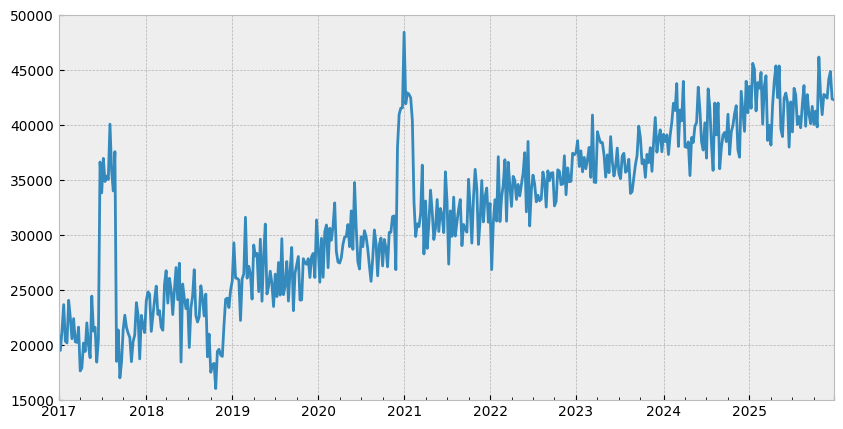

In [6]:
ts['unemployment_claim'].plot()

### Training time series models

#### Decompose a time series with `seasonal_decompose()`

Decomposition involves breaking down a time series into its constituent parts: trend, seasonal and residual components. The `period` argument is automatically inferred, we can change this value to match the seasonality we believe the data exhibits.

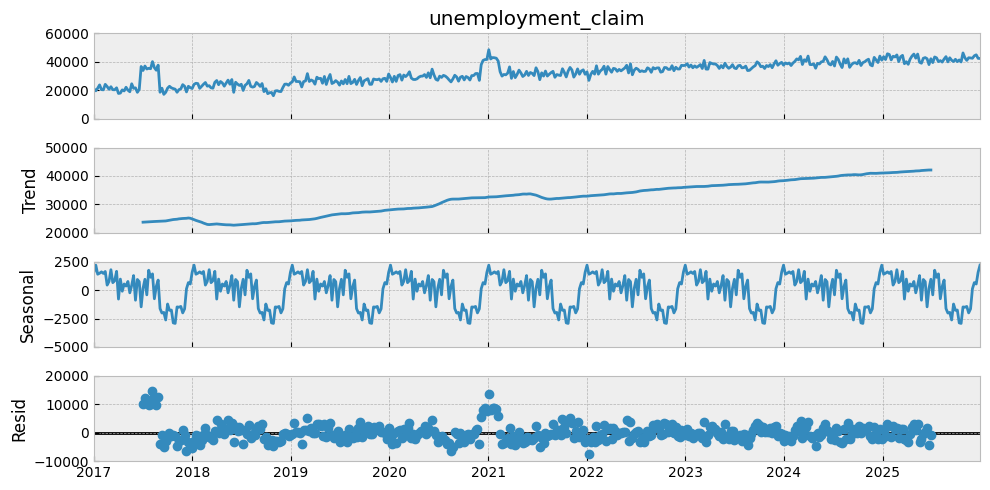

In [7]:
# seasonal decomposition
decomposition = seasonal_decompose(ts['unemployment_claim'], model='additive')
decomposition.plot()

plt.show()

#### What do we mean by an additive or multiplicative time series?

If fluctuations do not vary with the level of the time series, then we say the decomposition is additive, since we can add together the components to get the values of the series,

> Original time series  = trend + seasonality + residuals

If as the level of the series increases, the fluctuations also increase and vice versa then it's multiplicative, we need to multiply the components to get the values of the series,

> Original time series  = trend x seasonality x residuals

We can determine which composition our data has by whichever is least reliant on residuals, i.e. which of the following fits the data better:

- trend + seasonality
- trend x seasonality

In a perfect world, we would have additive residuals = 0 and multiplicative residuals = 1:

- trend + seasonality + 0
- trend x seasonality x 1

Apply an additive decomposition by setting `model='a'`

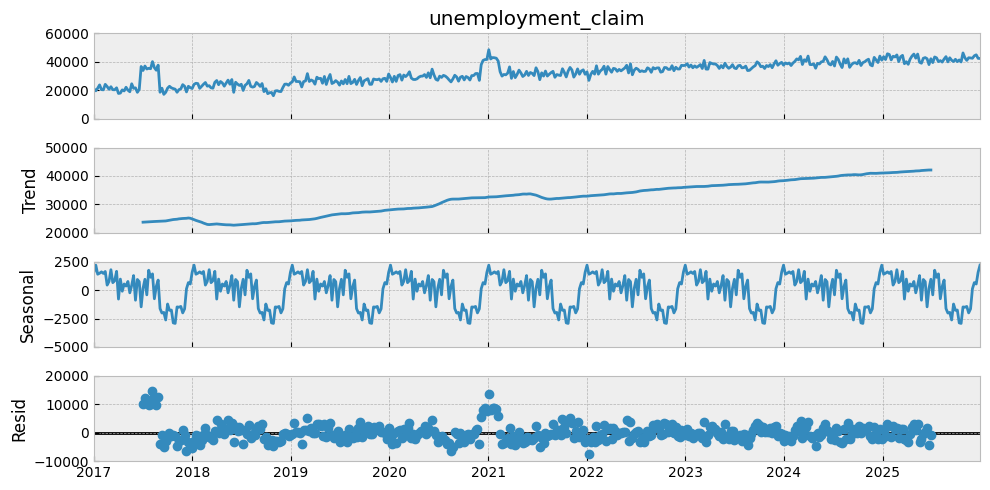

In [8]:
sdc_a = seasonal_decompose(ts['unemployment_claim'], model='a')
sdc_a.plot()
plt.show()

Extract and plot the denoised additive model to see how well an additive composition fits the data,

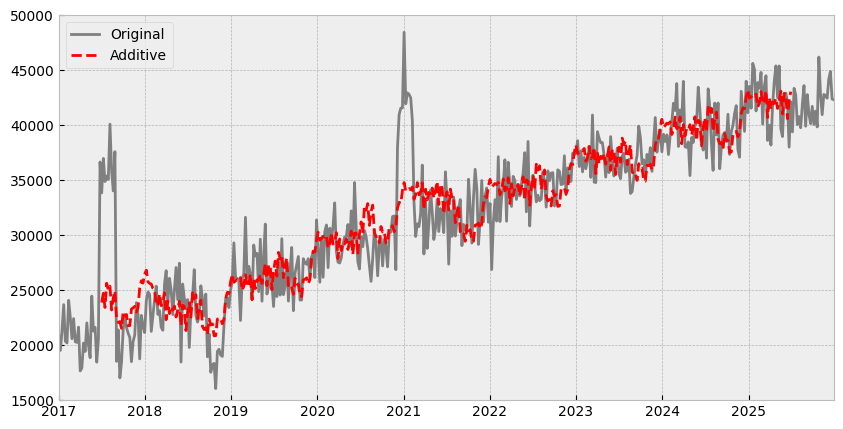

In [9]:
# This is the additive model, which is the sum of the trend and seasonal components. The residual component is not included in this model, as it represents the random noise in the data that cannot be explained by the trend and seasonality. By plotting the additive model against the original time series, we can visually assess how well the trend and seasonal components capture the underlying patterns in the data.
additive_model = sdc_a.trend + sdc_a.seasonal
# Plot the original time series and the additive model together to compare them. 
# The original time series is plotted in grey, while the additive model is plotted
plt.plot(ts['unemployment_claim'], label = 'Original', color='grey')
plt.plot(additive_model, label = 'Additive', linestyle='--', color='red')

plt.legend();

#### Challenge: Is an additive or multiplicative decomposition best suited for this data?

- Apply a multiplicative decomposition by setting `model='m'`
- Extract the denoised multiplicative model by modifying `additive_model` and renaming to `multiplicative_model`
- Plot the denoised multiplicative model alongside the original time series
- Compare to the results of the additive decomposition, which best describes this data?

Note: If the variance of the residuals changes quite dramatically over time (known as heteroscedasticity) or shows a pattern, this suggests that the decomposition is not suitable for the data.

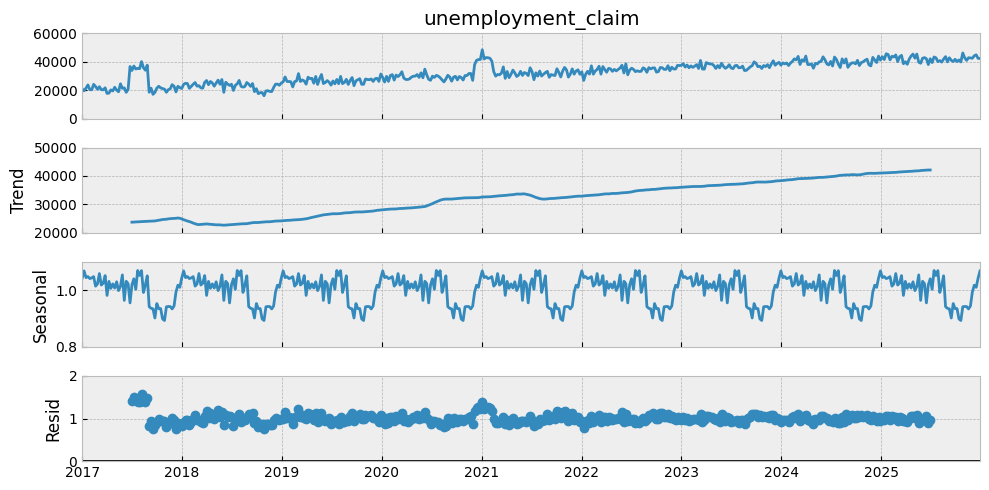

In [10]:
## multiplicative model

# What parameter should we use for the period in the multiplicative model?
sdc_m = seasonal_decompose(ts['unemployment_claim'], model='m')
sdc_m.plot()
plt.show()

Extract and plot the denoised multiplicative model to see how well an multiplicative composition fits the data,

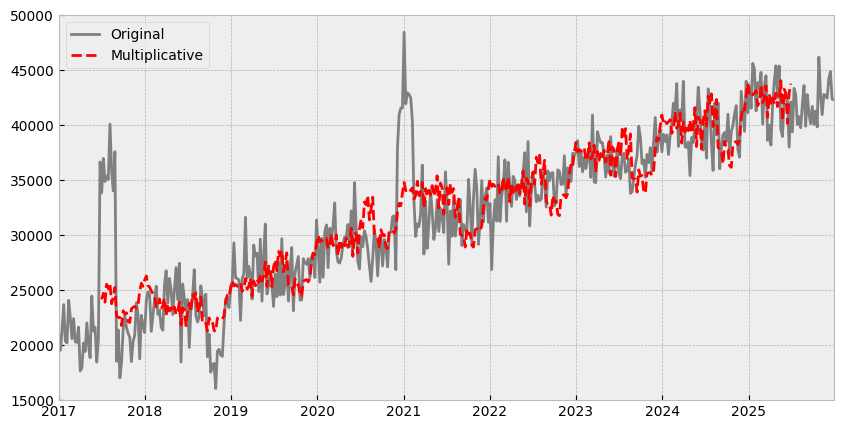

In [11]:
##
# What should be the sign here for the multiplicative model?
# what should we do to the trend and seasonal components for the multiplicative model?
multiplicative_model =  sdc_m.trend * sdc_m.seasonal

# How should we plot the multiplicative model against the original time series?

plt.plot(ts['unemployment_claim'], label = 'Original', color='grey')
plt.plot(multiplicative_model, label = 'Multiplicative', linestyle='--', color='red')
plt.legend();

You could practise in your own time by accessing this link:

https://kourentzes.com/forecasting/2014/11/09/additive-and-multiplicative-seasonality/

### Stationarity

A time series is stationary if its statistical properties, namely the mean and variance, do not change over time.

Many time series forecasting models require a time series to be stationary in order to effectively predict the future.

If we have a multiplicative time series, we can stablise the variance of the series by applying a `log` transformation.

#### Stablise the variance of a time series by applying a `log` transformation

If we find we have a multiplicative decomposition, it is generally a good idea to apply a `log` transformation to the data in order to make the variance stable.

The equation for a multiplicative decomposition is as follows: `y = T x S x R`

Where `T` denotes the trend component, `S` the seasonal component and `R` the residual/noise component.

Using the properties of logarithms. Applying a logarithm to a product yields a sum of logarithms, as follows:

`log(y) = log(T) + log(S) + log(R)`

Therefore by applying a log transformation to mulitplicative series, it effectively becomes an additive series.

We can the logarithm of the series using `.log()`, once we have finished our analysis we can returning a `.log()` transformed series to its original scale using `.exp()` so we can interpret the results.

### Testing for stationarity

A time series is stationary if it shows no obvious trend, no obvious seasonality and does not have a multiplicative decomposition.

Stationarity ensures that patterns in our series are relatively persistent over time, and can help mitigate the uncertainty, which in turn can enable us to predict future values with more accuracy.

How do we find out if a time series is stationary? we'll take a look at three ways:
- Eyeballing the graph
- Look at a series' ACF plot
- Running stationarity tests

In most cases our time series will not be perfectly stationary (we can expect this) and it depends on how strong the trend and seasonality we see are, we can explore stationarity qualitatively using the autocorrelation function and also quantitatively using the Augmented Dickey-Fuller (ADF) test.

#### Challenge: Check for stationarity by eyeballing the time series graph

Let's plot the level of the series with a rolling window. Do you observe signs of non-stationarity?

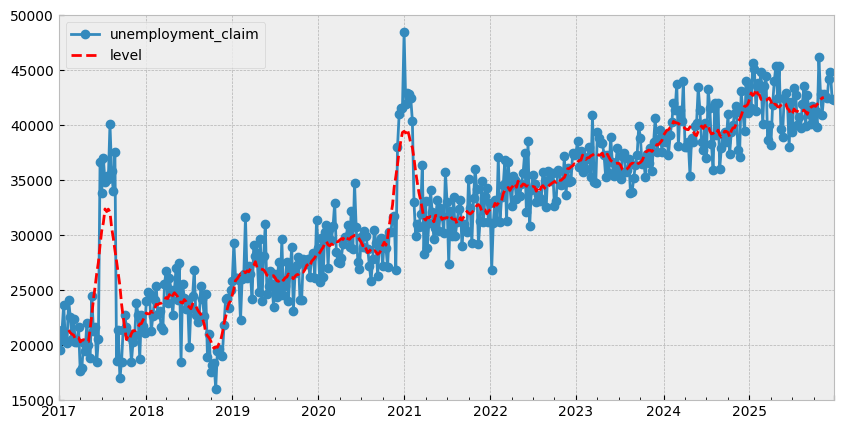

In [12]:
ts['unemployment_claim'].plot(marker='o');
# we can use rolling mean to estimate the level of the time series, which is the underlying trend without seasonality and noise. 
# We can use a window size of 13 to capture the yearly seasonality in the data.
level = ts['unemployment_claim'].rolling(window=13, center=True).mean()
level.plot(linestyle='--',label='level', color='red');
plt.legend();

#### Check for stationarity using `plot_acf()` from `statsmodels`

We can spot the presence of a trend through the slowly decaying correlation coefficients, therefore it is likely our time series is non-stationary.

There is evidence of seasonality with a seasonal period of 7 as we can see statistically significant upticks in the coefficients at lags 7 and 14.

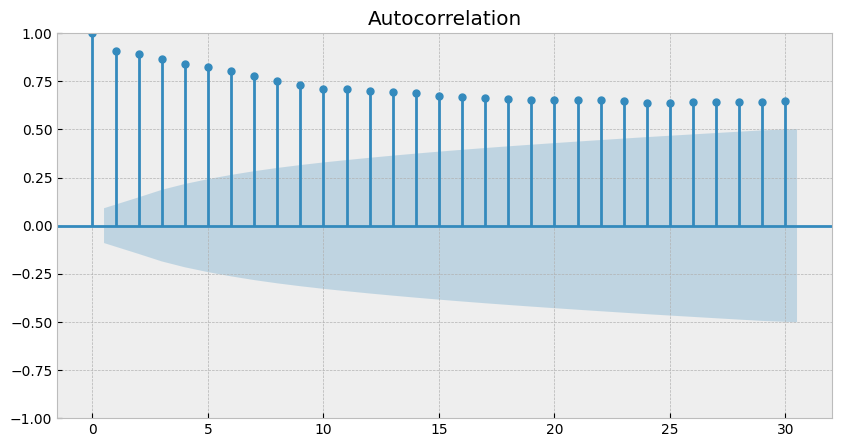

In [13]:
plot_acf(ts['unemployment_claim'], lags=30); # Try changing the number of lags to see how it affects the plot

#### Augmented Dickey-Fuller (ADF) test for stationarity


There are different types of statistical tests you can perform to test for stationarity, the most common ones fall under the category of unit root tests.

We will not dive into the specifics of unit root tests so it is suffice to say that they look for a very specific type of stationarity (the presence of a unit root) but there might be other types that can go undetected by these tests: for example, if a series has strong seasonality.

Despite this, they still provide a good starting point. They do detect the presence of a trend in the data, which is a type of non-stationarity. But we will also have to check for the presence of seasonality once the trend has been removed, to conclude that the series is stationary.

The ADF (Augmented Dickey-Fuller test), is a type of statistical test based on unit roots. The null and alternative hypotheses are as follows:

* H0: The series has a unit root and it **is NOT stationary**.
* H1: The series does not have a unit root and it **is stationary**.

Run an Augmented Dickey-Fuller (ADF) test for stationarity using  `adfuller()`

In [14]:
p_value_adf = adfuller(ts['unemployment_claim'])[1]

print(f'ADF Test p-value: {p_value_adf:.4f}')

ADF Test p-value: 0.4564


Looking through the documentation we can see that the `p-value` is the second item (index 1) in the output.

Therefore the p value is significantly less than  than 0.05, and therefore we can reject the null hypothesis, that the series has a unit root and it is NOT stationary.

#### Differencing a time series

We can stablise the mean of a time series through differencing `.diff()` and/or seasonal differencing `.diff(m)` to help make our time series stationary.

ARIMA models have a hyperparameter for differencing, it is important for us as analysts and programmers to determine what the hyperparameter `d` (differencing to reduce the trend) and `D` (differencing to reduce seasonality) should be.

##### Differencing to reduce trend using `.diff()`

Differencing entails subtracting consecutive observations of a time series.

If the increase in mean for each period is roughly constant (in other words, there is a linear trend), the trend would be mostly eliminated by first order differencing, as follows:

> y'<sub>t</sub> = y<sub>t</sub> - y<sub>t-1</sub>

Where y'<sub>t</sub> is the first order differenced series. We can apply first order differencing in Python using `.diff()`.

If the trend is quadratic, or non-linear, differencing once may not be enough to reduce the trend. You may need to perform second order differencing, i.e. subtract consecutive observations twice as follows:

> y''<sub>t</sub> = y'<sub>t</sub> - y'<sub>t-1</sub> = (y<sub>t</sub> - y<sub>t-1</sub>) - (y<sub>t-1</sub> - y<sub>t-2</sub>) = y<sub>t</sub> - 2y<sub>t-1</sub> + y<sub>t-2</sub>

We can apply second order differencing in Python using `.diff().diff()`. Higher order differencing is possible but rarely needed.

##### Seasonal differencing to reduce seasonality using `.diff(m)`

Seasonal differencing entails subtracting consecutive seasonal observations of a time series.

First order differencing seasonal differencing is as follows:

> y'<sub>t</sub> = y<sub>t</sub> - y<sub>t-m</sub>

Where y'<sub>t</sub> is the first order differenced series and `m` is the seasonal period. We can apply first order seasonal differencing in Python using `.diff(m)`.

Seasonal differencing once may not be enough to reduce the seasonality. You may need to perform second order seasonal differencing, i.e. subtract consecutive seasonal observations twice as follows:

> y''<sub>t</sub> = y'<sub>t</sub> - y'<sub>t-m</sub> = (y<sub>t</sub> - y<sub>t-m</sub>) - (y<sub>t-m</sub> - y<sub>t-2m</sub>) = y<sub>t</sub> - 2y<sub>t-m</sub> + y<sub>t-2m</sub>

We can apply second order seasonal differencing in Python using `.diff(m).diff(m)`.

Higher order seasonal differencing is also possible but is rarely needed.

##### Differencing a time series with both trend and seasonality

If a time series has both trend and seasonality, first order seasonal differencing may be enough to reduce both the trend and seasonality.

In some cases you may want to apply both differencing and seasonal differencing, for example:

> ts.diff(m).diff()

In most cases, we will not be able to completely remove our trend and seasonality i.e. our time series may not be perfectly stationary (we can expect this).

We favour the simplier solution of not differencing our data too many times, as this may have negative effects on the accuracy of our analysis. We recommend reducing enough so that we no longer have "strong" trend and seasonality.

#### Differencing with `.diff()` to reduce the trend

A way of removing/reducing trend in a time series is by differencing. Usually differencing once with `.diff()` is enough to make a time series stationary but we may need to apply second order differencing `.diff().diff()` or higher order differencing.

<Axes: >

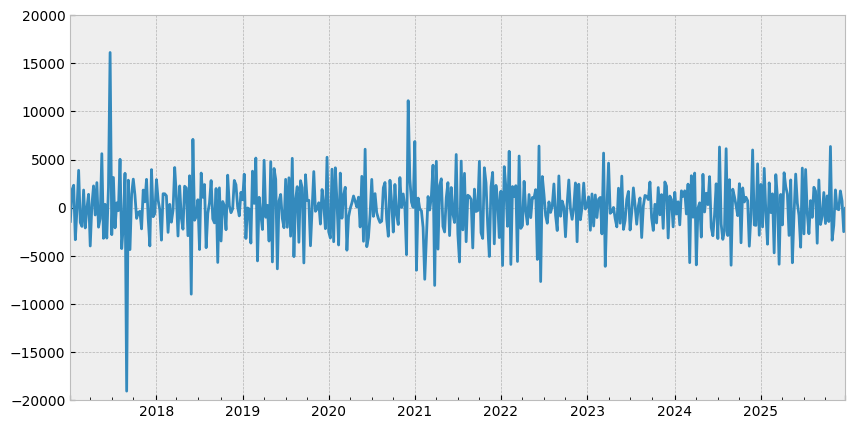

In [15]:
ts_diff = ts['unemployment_claim'].diff().dropna()
ts_diff.plot()

#### Challenge: Re-run `ACF` and `ADF` test, is our differenced time series stationary?

- Run the ADF test again to check for stationarity.
- The ADF test does not check for seasonality, so run an ACF plot again to check for seasonality.
- Jot down any results and observations.

Run the ADF test again to check for stationarity,

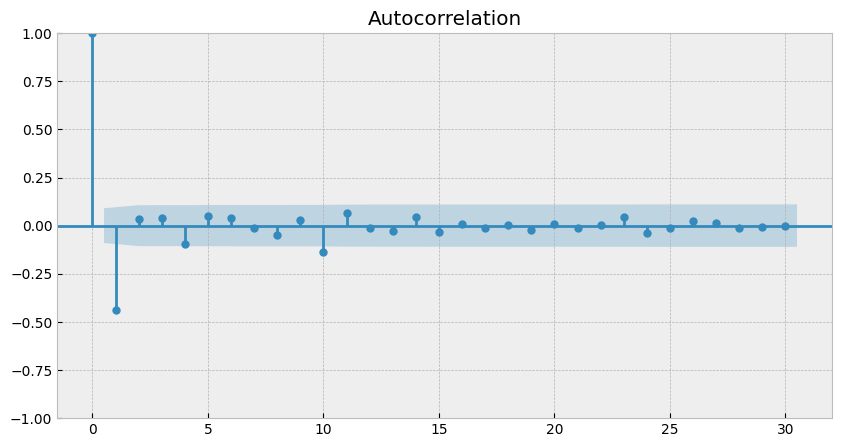

In [16]:
plot_acf(ts_diff, lags=30)
plt.show()

The p-value is now 0.0007 which is less than 0.05, and therefore we have sufficient evidence to reject the null hypothesis that the series has a unit root and it is NOT stationary.

In [17]:
p_value_adf = adfuller(ts_diff)[1]

print(f'ADF Test p-value: {p_value_adf:.4f}')

ADF Test p-value: 0.0000


### Time series forecasting - training the model

Here's a brief overview of each of these time series forecasting methods:

1. **Exponential Smoothing Models**: used for forecasting time series data by applying weighted averages of past time points where the weights decrease exponentially over time.

2. **Moving Average Models**: forecast future values based on the average of past data points.

3. **Autoregressive Models**: forecast future values of a time series using a linear combination of its own previous values.

4. **Box-Jenkins Models**: The Box-Jenkins methodology, also known as ARIMA (Autoregressive Integrated Moving Average), is a sophisticated approach that combines autoregressive models, moving averages, and differencing to make a non-stationary time series stationary. The model is versatile and can handle a variety of time series patterns, making it one of the most commonly used forecasting methods.

5. **Deep Learning Models**: Deep learning models, are also popular, these models are capable of capturing complex patterns in large volumes of data, handling nonlinear relationships, and considering long-term dependencies in the data.

6. **Tree-Based Models**: Tree-based models, such as Random Forest and XGBoost, can be adapted for time series forecasting by transforming the time series into a supervised learning problem using lagged features. These models are capable of capturing nonlinear relationships and interactions between features, making them suitable for complex time series data.

Each of these methods has its strengths and is suitable for different types of time series data and forecasting requirements.

- Exponential smoothing models:
    - Single exponential smoothing (SES)
    - Double exponential smoothing / Holt's exponential smoothing (HES)
    - Triple exponential smoothing / Holt-Winters exponential smoothing (HWES)
    - Exponential smoothing state space model with Box-Cox transformation, ARMA errors, Trend and Seasonal components (TBATS)


- Moving average models:
    - Moving average (MA)
    - Exponential moving average (EMA)
    - Exponentially weighted moving average (EWMA)
    
    
- Autoregressive models:
    - Autoregression (AR)
    - Vector Autoregression (VAR)
    - Autoregressive conditional heteroskedasticity (ARCH)
    - Generalized autoregressive conditional heteroskedasticity (GARCH)

- Box-jenkins models:
    - Autoregressive moving average (ARMA)
    - Autoregressive integrated moving average (ARIMA)
    - ARIMA with exogenous variables (ARIMAX)
    - Seasonal autoregressive integrated moving average (SARIMA)
    - SARIMA with exogenous variables (SARIMAX)


- Deep learning models:
    
    - Multilayer perceptron (MLP)
    - Convolutional neural network (CNN)
    - Long short term memory (LSTM)

### How do you forecast and evaluate a Time Series model?

There are several metrics to evaluate how informative and accurate a time series model is, such as:

- Forecast error

    - for every time period `t` in our dataset we take the difference between actual values and fitted values (values that we estimate using our model for the same time periods).

- Mean absolute error (MAE)

    - This metric involves taking the average of the absolute values of forecast errors at each period `t`, capturing the magnitude of the error (in other words how spread out the values are) rather than the direction of this effect (whether the error is positive or negative). It will also avoid errors of opposite signs cancelling each other out.

- Mean squared error (MSE)

    - The difference between the MSE and the previous metric (MAE) is that, instead of taking the absolute value of errors at each time period `t` and averaging them, we are now squaring the differences, this will more greatly penalise larger errors.

- Root mean square error (RMSE)

    - The square root of the MSE, this brings the MSE back to the same scale as the raw data.

- Mean absolute percentage error (MAPE)

    - A scale-independent metric, which means that error sizes are not sensitive to the scale of the series, however, this metric can be unstable.

The choice of error metric to use when evaluating your model depends entirely on the use case.

### How do you build a Time Series model in python?

#### Train-test split for time series

We need to split our data into a train set to fit the model, and a test set that will be unseen by the model, usually the last 10-30% observations in the dataset (depending on its size) to evaluate our predictions.

Because we are working with chronologically ordered time series data, we cannot use the usual `train_test_split` function in `sklearn` as it relies on random sampling. Instead, we generally use the first 70-90% of observations in our dataset as a train set, and the remainder as test set.

Performing this type of train/test split in Python is as simple as choosing the number of observations we want to use for the test set and then using standard slicing notation.

Split the data with the first 80% of data points in the training set and the final 20% in the test set,

In [18]:
threshold = int(len(ts) * 0.8)

train = ts['unemployment_claim'][:threshold]
test = ts['unemployment_claim'][threshold:]

#### Building a baseline time series model

First, it is good practice to establish a baseline model so that we have something to compare our model performances to.

For our baseline model we will use the Persistence Algorithm (the “naive” forecast).

This uses the previous value in the series to predict the expected outcome of the next value in the time series.

Generate the naive forecasts with `.shift()`

In [19]:
# generate the naive predictions, which is the value of the previous time step

ts['naive_pred'] = ts['unemployment_claim'].shift(1)



In [20]:
ts.tail()

,unemployment_claim,retail_closure,naive_pred
2025-11-30,"42,449",10,"42,670"
2025-12-07,"44,184",11,"42,449"
2025-12-14,"44,875",12,"44,184"
2025-12-21,"42,376",9,"44,875"
2025-12-28,"42,310",9,"42,376"


Plot the naive forecasts for the test set,

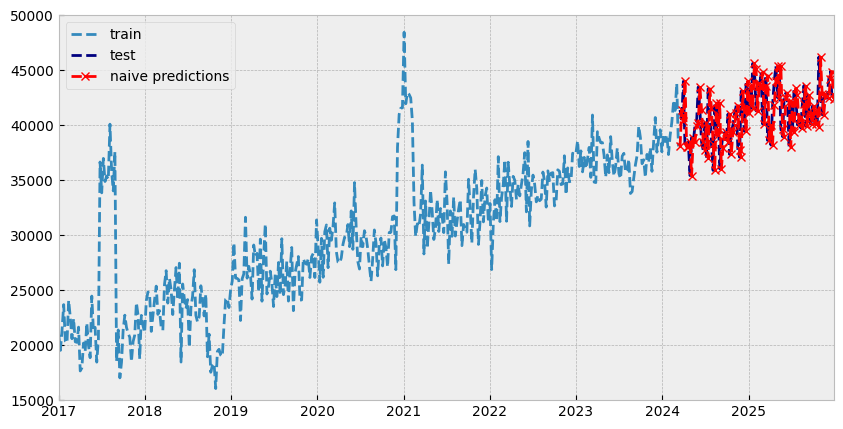

In [21]:
plt.plot(train, label="train", linestyle='--')
plt.plot(test, label="test", color="navy", linestyle='--')

plt.plot(ts['naive_pred'][threshold:], label="naive predictions", marker = 'x', linestyle='--', color='red')

plt.legend(loc='upper left');

To measure performance, we can use the RMSE evaluation metric by first calculating the MSE score using `mean_squared_error()` from `sklearn` and then taking the square root using `sqrt()` from `math` as follows,

In [22]:
# calculate the test score using root mean squared error (RMSE)
test_score_naive = math.sqrt(mean_squared_error(test, ts['naive_pred'][threshold:]))
test_score_naive

2875.856440323778

We get an RMSE score of 8863, we use this to check if our machine learning forecasting models are doing their job correctly.

We will know whether they are performing better than the baseline model if they can achieve a lower RMSE score than the baseline model.

The goal is to to minimise this score.

#### Modelling with `AutoARIMA`

We can use `AutoARIMA` from `pmdarima` which will automatically determine the best hyperparameter values `(p,d,q)(P,D,Q)m`, where,

- p is the order (number of lags) incorporated into our model
- d is the degree of differencing (the number of times the data have had past values subtracted)
- q is the number of past error terms incorporated into our model
- P is the number of seasonal lags incorporated into our model
- D is the degree of seasonal differencing
- Q is the number of past seasonal error terms incorporated into our model
- m is the seasonal period

As analysts and programmers, it is good practice to determine and set `d` and `D` ourselves, as sometimes the model struggles to test and converge for these values. We should also provide a range of `p` and `q` to narrow the search space as follows,

In [23]:
# autoarima_model = pm.arima.AutoARIMA(start_p=0 ,max_p=1, d=0, start_q=0, max_q=1,
#                                      start_P=0, max_P=1, D=1, start_Q=0, max_Q=1, m=13)
# simple model for display
autoarima_model = pm.arima.AutoARIMA(start_p=0 ,max_p=0, d=0, start_q=0, max_q=0,
                                     start_P=0, max_P=0, D=0, start_Q=0, max_Q=0, m=13)

autoarima_model.fit(train)

,start_p,0
,d,0
,start_q,0
,max_p,0
,max_d,2
,max_q,0
,start_P,0
,D,0
,start_Q,0
,max_P,0
,max_D,1


We can look at a summary of the model generated by `AutoARIMA` using `.summary()`

In [24]:
autoarima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  376
Model:                        SARIMAX   Log Likelihood               -3824.568
Date:                Thu, 12 Mar 2026   AIC                           7653.135
Time:                        16:05:45   BIC                           7660.995
Sample:                    01-01-2017   HQIC                          7656.255
                         - 03-10-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2.996e+04    326.543     91.739      0.000    2.93e+04    3.06e+04
sigma2      4.005e+07    3.8e+06     10.544      0.000    3.26e+07    4.75e+07
===================================================================================
Ljung-Box (L1) (Q):                 289.42   Jarque-Bera (JB):                10.51
Prob(Q):                              0.00   Prob(JB):                         0.01
Heteroskedasticity (H):               0.70   Skew:                            -0.04
Prob(H) (two-sided):                  0.04   Kurtosis:                         2.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Generate and plot the predictions made by the `AutoArima` model,

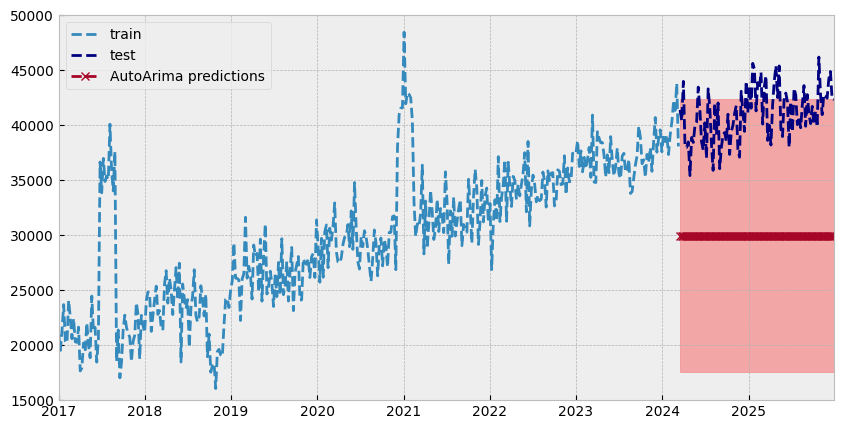

In [25]:
prediction, confint = autoarima_model.predict(n_periods=test.shape[0], return_conf_int=True)
autoarima_preds = pd.Series(prediction, index=test.index)
cf = pd.DataFrame(confint)

plt.plot(train, label="train", linestyle='--')
plt.plot(test, label="test", color="navy", linestyle='--')
plt.plot(autoarima_preds, label="AutoArima predictions", marker = 'x', linestyle='--')
plt.fill_between(test.index, cf[0], cf[1], alpha=.3, color='red')
plt.legend(loc='upper left');

Use RMSE evaluation metric by using `mean_squared_error()` from `sklearn` and `sqrt()` from `math` to measure performance

In [26]:
test_score_autoarima = math.sqrt(mean_squared_error(test, autoarima_preds))
test_score_autoarima

11343.632908073401

Compare the RMSE scores. what does it tell?

Therefore, we know our machine learning `AutoArima`	forecasting model is performing much better than the baseline model.

#### Challenge: Report key parameters of a time series model and intepret them

What hyperparameter values were outputted from `AutoArima` and are they the best choice based on our analysis?

- p=
- d=
- q=

- P=
- D=
- Q=

- m=

#### Create the the prediction interval of ARIMA

In [27]:
# Answer 

predict_period = test.shape[0]+12
start_date = test.index[0]

preds, confint = autoarima_model.predict(n_periods=predict_period, return_conf_int=True)
autoarima_preds = pd.Series(preds, index=pd.date_range(start_date, periods=predict_period, freq='W'))
autoarima_confint_lower = confint[:, 0]
autoarima_confint_upper = confint[:, 1]


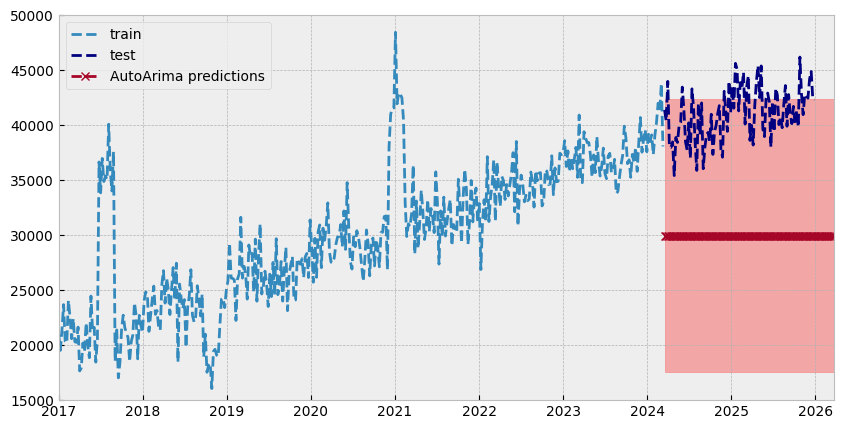

In [28]:

plt.plot(train, label="train", linestyle='--')
plt.plot(test, label="test", color="navy", linestyle='--')
plt.plot(autoarima_preds, label="AutoArima predictions", marker = 'x', linestyle='--')
plt.fill_between(autoarima_preds.index, autoarima_confint_lower, autoarima_confint_upper, alpha=.3, color='red')
plt.legend(loc='upper left');

<hr /> <div style='page-break-after: always; display: none'>\pagebreak</div>

### Tree-Based Time Series Forecasting

Tree-based models like Random Forest and XGBoost can be used for time series forecasting by creating lagged features from the time series data. This transforms the forecasting problem into a supervised learning regression task.

#### Feature Engineering for Time Series
To apply tree-based models, we create features such as:
- Lagged values (e.g., value at t-1, t-2, etc.)
- Rolling statistics (e.g., moving averages)
- Seasonal indicators
- Other exogeneous indicators
- A mixture of the above


#### Implementation in Python

In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [30]:
# Load the copied time series data
data = ts


In [31]:
# Create lagged 1 and 2 as features 
# fill in the lag1
data['claim_lag1'] = data['unemployment_claim'].shift(1)
data['claim_lag2'] = data['unemployment_claim'].shift(2)
data['moving_avg_13'] = data['unemployment_claim'].rolling(window=13).mean()
data['retail_closure_lag1'] = data['retail_closure'].shift(1)
# create 13 week moving average as another feature

#### Split the feature and target time series

In [32]:

data = data.dropna()

# use lagged features variable to create the train test set
X = data.drop('unemployment_claim', axis=1)
y = data['unemployment_claim']

### Train test split

In [34]:
data.shape

(458, 7)

In [36]:

# Train-test split (use last 26 weeks for testing)
threshold = int(len(data) * 0.8)
train_size = threshold
#
# How do we split the data into train and test sets for time series forecasting?
# We need to make sure that the training set contains only data from before the test set, to avoid data leakage.
X_train, X_test = X[:train_size], X[train_size:]
# how do we split the target variable?

y_train, y_test = y[:train_size], y[train_size:]

In [37]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=20, random_state=42)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

#### Calculate the performance using training data

In [38]:

rf_predictions_train = rf_model.predict(X_train)
rf_mse_train = mean_squared_error(y_train, rf_predictions_train)
rf_mae_train = mean_absolute_error(y_train, rf_predictions_train)
rf_rmse_train = np.sqrt(rf_mse_train)

print(f"Random Forest - Train MSE: {rf_mse_train:.2f}, Train MAE: {rf_mae_train:.2f}, Train RMSE: {rf_rmse_train:.2f}")


Random Forest - Train MSE: 420666.10, Train MAE: 385.41, Train RMSE: 648.59


#### Challenge: Evaluate the performance of Random forest using test data

**Task**

* Make predictions on the time series using test data
* Create the evaluation metrics 
* Print the result

In [39]:
# Make predictions
rf_predictions = rf_model.predict(X_test)
# Calculate metrics
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

print(f"Random Forest - MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

Random Forest - MSE: 9726481.63, MAE: 2722.10, RMSE: 3118.73


* What do we observe from the RMSE here ? Better or worse than ARIMA and seasonal?

### Let's train another model - Gradient Boosting Regressor

In [40]:
# Train Gradient Boosting model
gradient_model = GradientBoostingRegressor(n_estimators=20, random_state=42)
gradient_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",20
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft c

### Evaluate the performance using training data

In [42]:
gradient_model_train_preds = gradient_model.predict(X_train)
gradient_model_mse_train = mean_squared_error(y_train, gradient_model_train_preds)
gradient_model_mae_train = mean_absolute_error(y_train, gradient_model_train_preds)
print(f"Gradient Boosting Train MSE: {gradient_model_mse_train:.2f}")
print(f"Gradient Boosting Train MAE: {gradient_model_mae_train:.2f}")
rf_grad = np.sqrt(gradient_model_mse_train)
print(f"Gradient Boosting Train MSAE: {rf_grad:.2f}")

Gradient Boosting Train MSE: 2409504.76
Gradient Boosting Train MAE: 1180.68
Gradient Boosting Train MSAE: 1552.26


#### Challenge: Evaluate the performance of Gradient Boosting using test data

**Task**

* Make predictions on the time series using test data
* Create the evaluation metrics 
* Print the result

In [43]:

# Make predictions
gradient_model_predictions = gradient_model.predict(X_test)


In [44]:

# Calculate metrics
gradient_model_mse = mean_squared_error(y_test, gradient_model_predictions)
gradient_model_mae = mean_absolute_error(y_test, gradient_model_predictions)
gradient_model_rmse = np.sqrt(gradient_model_mse)

print(f"Gradient Boosting - MSE: {gradient_model_mse:.2f}, MAE: {gradient_model_mae:.2f}, RMSE: {gradient_model_rmse:.2f}")

Gradient Boosting - MSE: 19450465.81, MAE: 4197.66, RMSE: 4410.27


#### Visualise the results

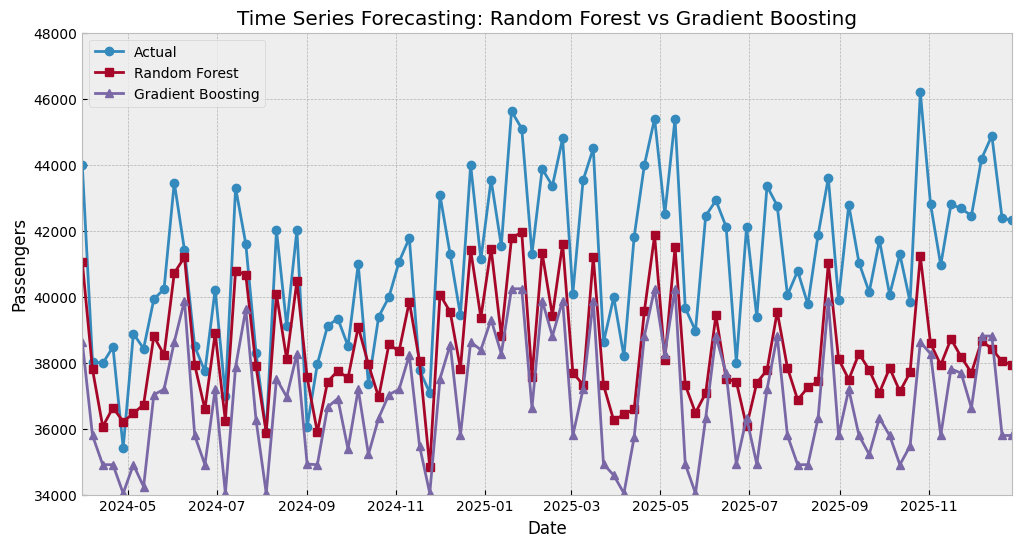

In [45]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, rf_predictions, label='Random Forest', marker='s')
plt.plot(y_test.index, gradient_model_predictions, label='Gradient Boosting', marker='^')
plt.title('Time Series Forecasting: Random Forest vs Gradient Boosting')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


####

### Create a table to show the performance of all models

In [46]:
# Put a table comparing the performance of all the models we have trained so far, including the naive forecast, SES, AutoARIMA, SARIMAX, Random Forest, and XGBoost. The table should include the RMSE for each model.
performance_data = {
    'Model': ['Naive Forecast',  'AutoARIMA', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [test_score_naive, test_score_autoarima, rf_rmse, gradient_model_rmse]
}
performance_df = pd.DataFrame(performance_data)
print(performance_df)

               Model   RMSE
0     Naive Forecast  2,876
1          AutoARIMA 11,344
2      Random Forest  3,119
3  Gradient Boosting  4,410


#### Performance Comparison
Tree-based models offer several advantages for time series forecasting:
- **Handling Nonlinearity**: They can capture complex nonlinear patterns in the data.
- **Feature Interactions**: Automatically model interactions between lagged features.
- **Robustness**: Less sensitive to outliers compared to linear models.
- **Interpretability**: Feature importance can provide insights into which lags are most predictive.

However, they may require more computational resources and careful hyperparameter tuning. In this example, we compared Random Forest and XGBoost on the air passengers dataset. The choice between them depends on the specific dataset and computational constraints.

### Review: Time Series Analysis

#### What did we learn?

* Describe a time series as a composition between trends, seasonality and residuals
* Describe the core terminology of time series analysis e.g. lags, stationarity, decomposition etc.
* Perform autocorrelation analysis
* Build and train a time series model
* Compare and contrast various approaches to time series analysis

#### What should I learn next?

#### Practice: Time Series
In the next workshop you will gain more experience with time series decomposition, understanding stationarity, pre-processing time series data for building forecasting models, and building and evaluating an ARIMA forecasting model.


#### Learning Objectives
- Choose the best decomposition model for a time series by comparing plots and residuals
- Implement and interpret ACF plots of a time series
- Identify stationarity and test for it using the ADF test, together with ACF plot
- Make a time series stationary through differencing
- Perform the steps to fit an ARIMA forecasting model to time series data
- Evaluate the performance of an ARIMA forecasting model

## Appendix

### What packages does this chapter use?

```python
import pandas as pd
from matplotlib import pyplot as plt
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error
import math
import random
import warnings
warnings.filterwarnings("ignore")
```

---

# END